# Ethiopia Financial Inclusion — Exploratory Data Analysis (Task 2)

**Author:** Yostina Abera  
**Dataset:** `data/processed/ethiopia_fi_unified_data_enriched.csv` (87 records)

This notebook explores the unified dataset to understand what drives financial inclusion in Ethiopia, why headline account ownership stagnated at **+3pp (2021→2024)** despite 65M+ mobile-money registrations, and which data gaps most limit forecasting.

Figures are rendered by tested functions in `src/eda.py` (Okabe-Ito colorblind-safe palette, no dual-axis charts) and also saved to `reports/figures/`. Interpretation is grounded in **Sheet D (Market Nuances)** of the enrichment guide: P2P is used for commerce (not just transfers), mobile-money-*only* users are ~0.5%, bank accounts are easily accessible, and credit penetration is very low.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # repo root on path
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from src import eda
from src.load_data import load_all

d, obs = eda._load()
pd.set_option('display.max_rows', 120)
print('Loaded', len(d['unified']), 'records;', obs.indicator_code.nunique(), 'indicators')

Loaded 87 records; 30 indicators


## 1. Dataset overview
Composition by `record_type`, `pillar` and `source_type`, plus the confidence mix.

In [2]:
u = d['unified']
overview = {
    'by record_type': u.record_type.value_counts(),
    'by pillar (obs/target/impact)': u[u.pillar.notna()].pillar.value_counts(),
    'by source_type': u.source_type.value_counts(),
    'by confidence': u.confidence.value_counts(),
}
for k, v in overview.items():
    print(f'\n=== {k} ==='); print(v.to_string())


=== by record_type ===
record_type
observation    50
impact_link    21
event          13
target          3

=== by pillar (obs/target/impact) ===
pillar
ACCESS           32
USAGE            23
GENDER           11
AFFORDABILITY     4
DEPTH             3
QUALITY           1

=== by source_type ===
source_type
survey        20
operator      18
regulator     11
research       9
policy         3
news           3
calculated     2

=== by confidence ===
confidence
high      62
medium    25


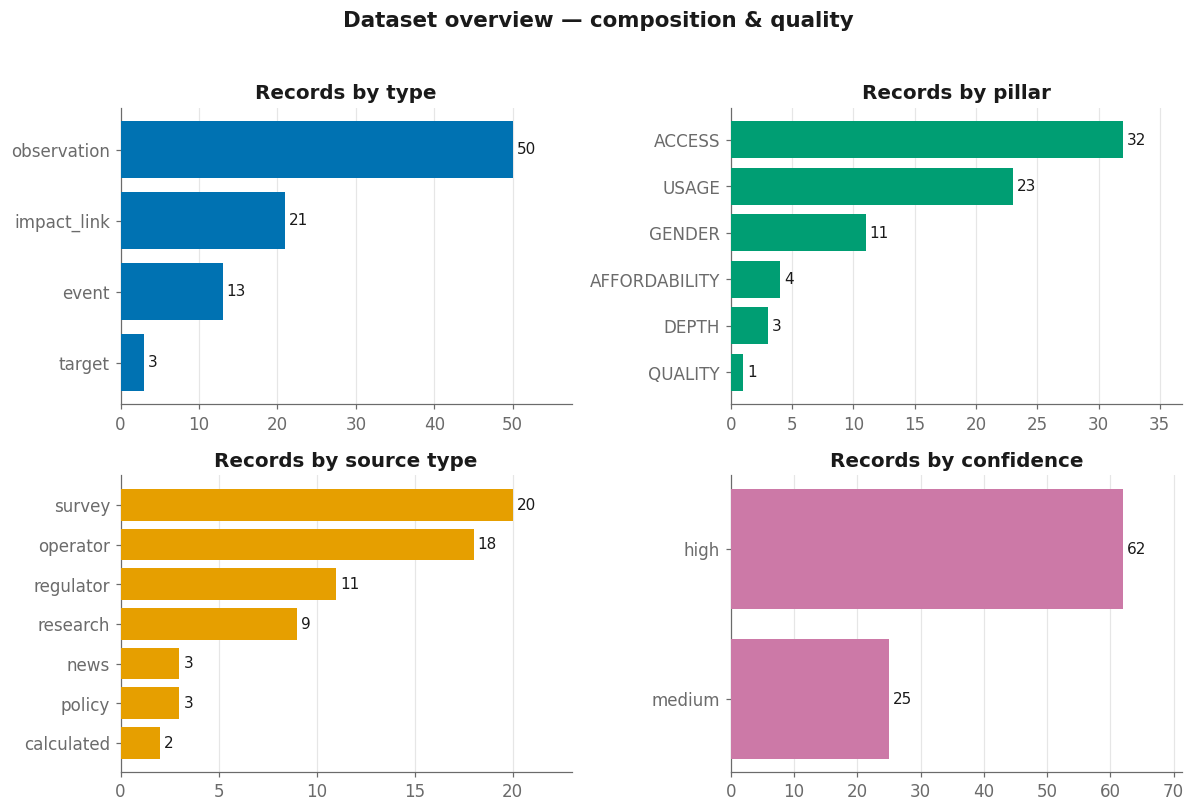

In [3]:
_ = eda.fig_overview(d)

## 2. Temporal coverage & data gaps
Which indicator has data in which year? The heatmap makes the **sparsity** obvious: only account ownership and Telebirr users form multi-point time series; most indicators are single snapshots.

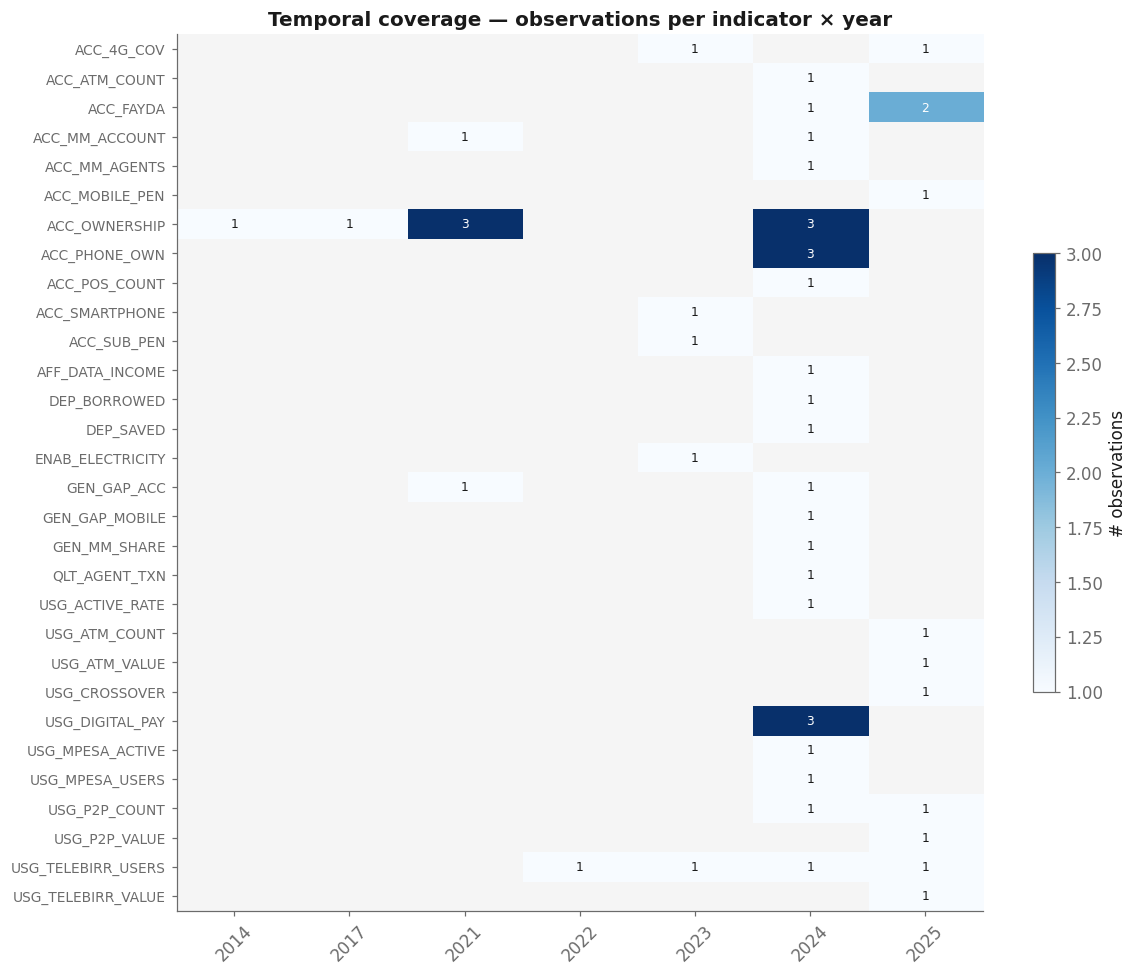

In [4]:
fig, piv = eda.fig_coverage(obs)  # inline auto-displays the open figure

In [5]:
# Sparsity summary: distinct years of coverage per indicator
cov = (obs.groupby('indicator_code')
          .agg(n_obs=('value_numeric','size'),
               years=('year', lambda s: sorted(s.unique().tolist())))
          .assign(n_years=lambda x: x['years'].map(len))
          .sort_values(['n_years','n_obs'], ascending=False))
single = cov[cov.n_years == 1]
print(f'{len(cov)} indicators total; {len(single)} have data in only ONE year '
      f'({len(single)/len(cov):.0%}). Only {(cov.n_years>=2).sum()} span >=2 years.')
print('\nMulti-year series (usable for trend estimation):')
print(cov[cov.n_years >= 2][['n_obs','years']].to_string())

30 indicators total; 23 have data in only ONE year (77%). Only 7 span >=2 years.

Multi-year series (usable for trend estimation):
                    n_obs                     years
indicator_code                                     
ACC_OWNERSHIP           8  [2014, 2017, 2021, 2024]
USG_TELEBIRR_USERS      4  [2022, 2023, 2024, 2025]
ACC_FAYDA               3              [2024, 2025]
ACC_4G_COV              2              [2023, 2025]
ACC_MM_ACCOUNT          2              [2021, 2024]
GEN_GAP_ACC             2              [2021, 2024]
USG_P2P_COUNT           2              [2024, 2025]


## 3. Data-quality assessment
Confidence is high for official/operator figures and medium for secondary sources. One systematic correction was applied upstream in `build_processed_dataset.py`: the starter main-sheet documentation columns were shifted one position left (`comparable_country` held the collector name, `collected_by` held a date, etc.); the processed data restores the intended alignment. See `reports/data_quality_assessment.md` for the full limitations register.

In [6]:
qual = (u.assign(one=1)
         .pivot_table(index='pillar', columns='confidence', values='one',
                      aggfunc='sum', fill_value=0))
print('Confidence by pillar:'); print(qual.to_string())
print('\nShare high-confidence:', f"{(u.confidence=='high').mean():.0%}")

Confidence by pillar:
confidence     high  medium
pillar                     
ACCESS           21      11
AFFORDABILITY     2       2
DEPTH             2       1
GENDER            7       4
QUALITY           0       1
USAGE            17       6

Share high-confidence: 71%


## 4. Access analysis — the account-ownership story
### 4.1 Trajectory (2014–2024) with events overlaid

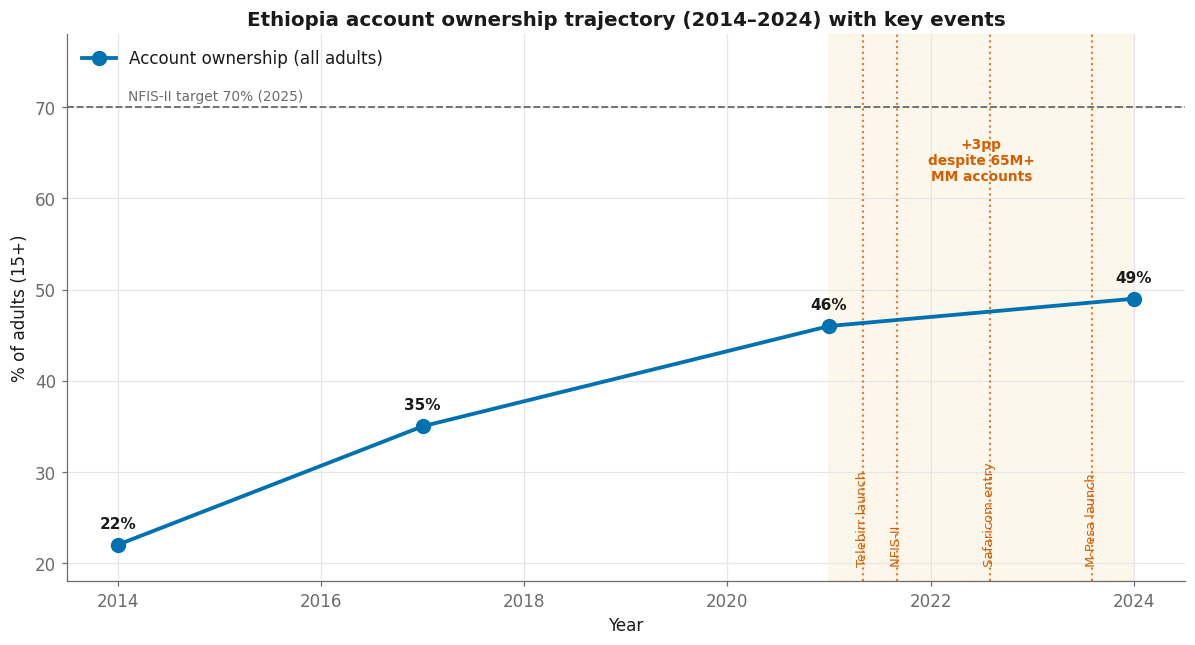

In [7]:
_ = eda.fig_access_trajectory(obs, d)

### 4.2 Growth is decelerating
Annualized gain fell from **+4.3pp/yr (2014–17)** to **+1.0pp/yr (2021–24)** — the period of the biggest mobile-money push.

   period  pp_total  pp_per_yr
2014–2017      13.0   4.333333
2017–2021      11.0   2.750000
2021–2024       3.0   1.000000


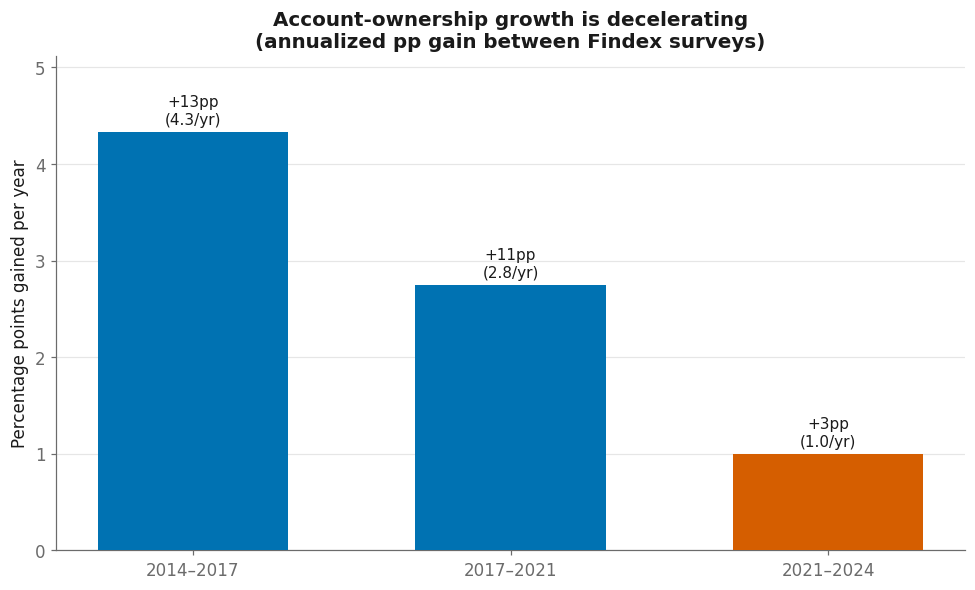

In [8]:
fig, g = eda.fig_growth(obs)
print(g.to_string(index=False))

### 4.3 Gender gap
The gap narrowed from ~20pp to ~15pp, but women's ownership (42%) still trails men's (57%). A key mechanism is device access: only 33% of women own a phone vs 50% of men.

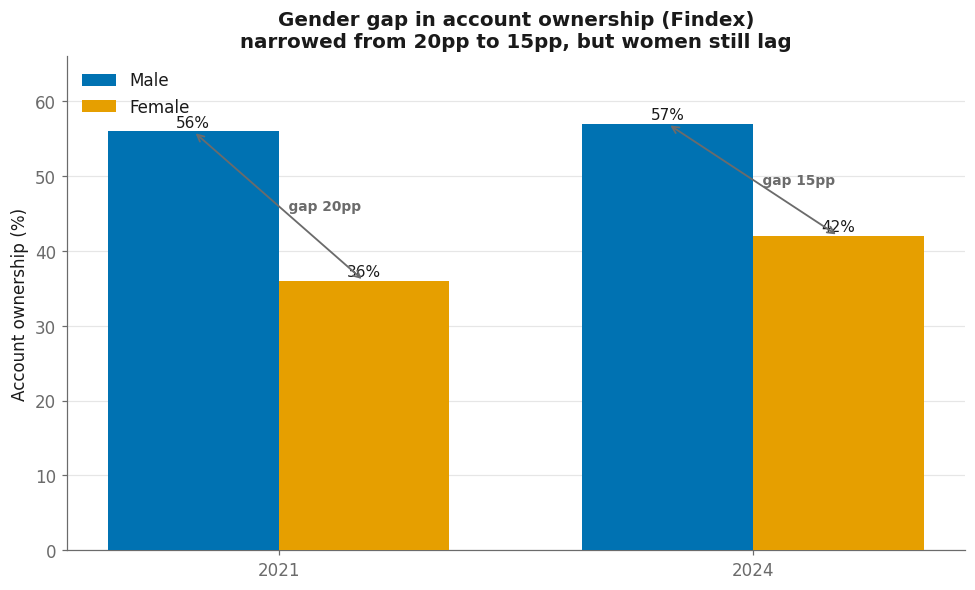

In [9]:
_ = eda.fig_gender(obs)

### 4.4 Why the 2021–2024 slowdown?
Account ownership rose only **46%→49%** while Telebirr alone registered ~55M accounts. The Market-Nuance explanation: Ethiopia's bank accounts are already easily accessible, and mobile-money-*only* users are ~0.5%, so most Telebirr/M-Pesa sign-ups went to people who **already had an account** — adding a payment channel, not a new account-holder. Findex counts *any* account, so those registrations barely move the headline. The binding constraints are now demand-side: phone ownership (41%), smartphone adoption (40%) and financial literacy — not the supply of accounts.

## 5. Usage (digital payments) analysis
### 5.1 The measurement paradox: operator registrations vs survey ownership

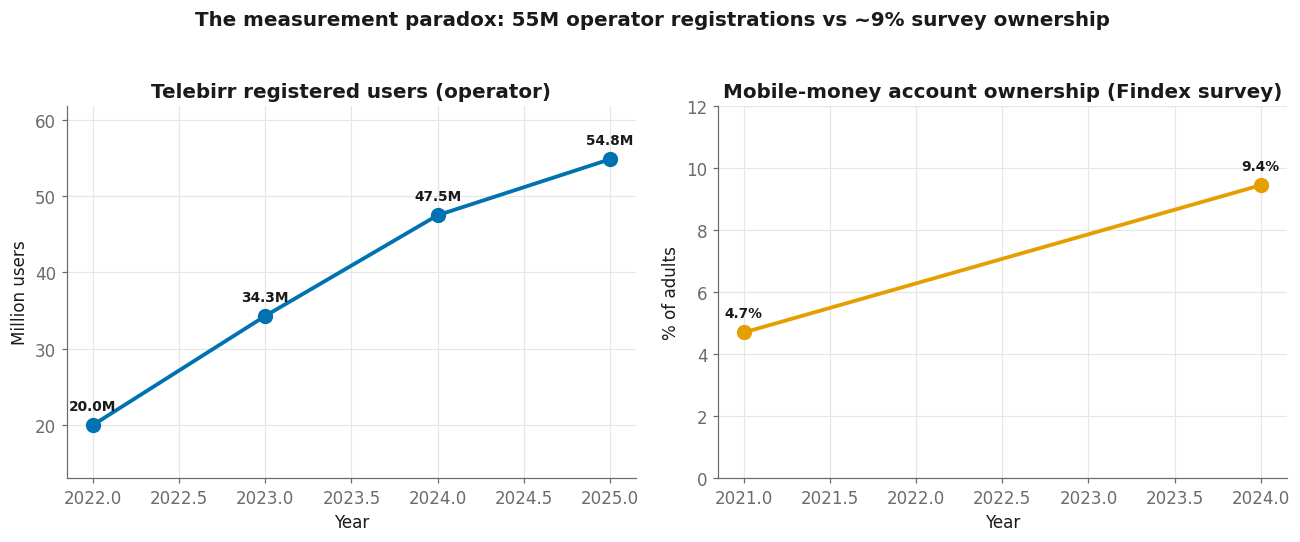

In [10]:
_ = eda.fig_usage_growth(obs)

### 5.2 Registered ≠ active ≠ unique owner
Operator registration counts massively overstate unique inclusion.

Total registered (Telebirr+M-Pesa): 65.6M
M-Pesa active rate: 66% (7.1M of 10.8M)
Findex mobile-money account ownership: 9.45% of adults (~6.6M)


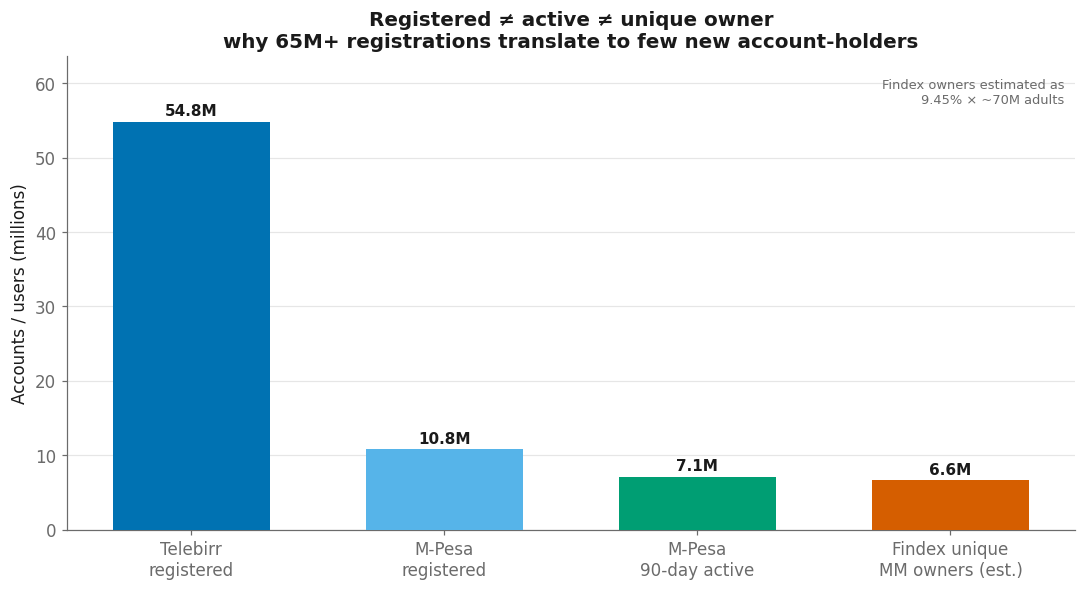

In [11]:
eda.fig_registered_active(obs)
# quantify the gaps
tb = eda._series(obs,'USG_TELEBIRR_USERS').value_numeric.max()
mp = eda._series(obs,'USG_MPESA_USERS').value_numeric.max()
mp_act = eda._series(obs,'USG_MPESA_ACTIVE').value_numeric.max()
print(f'Total registered (Telebirr+M-Pesa): {(tb+mp)/1e6:.1f}M')
print(f'M-Pesa active rate: {mp_act/mp:.0%} (7.1M of 10.8M)')
print('Findex mobile-money account ownership: 9.45% of adults (~6.6M)')

### 5.3 P2P has overtaken ATM withdrawals
Digital P2P (used for commerce, per Nuance D) crossed above ATM transaction counts — a genuine behavioural shift toward digital rails even as *account* growth stalled.

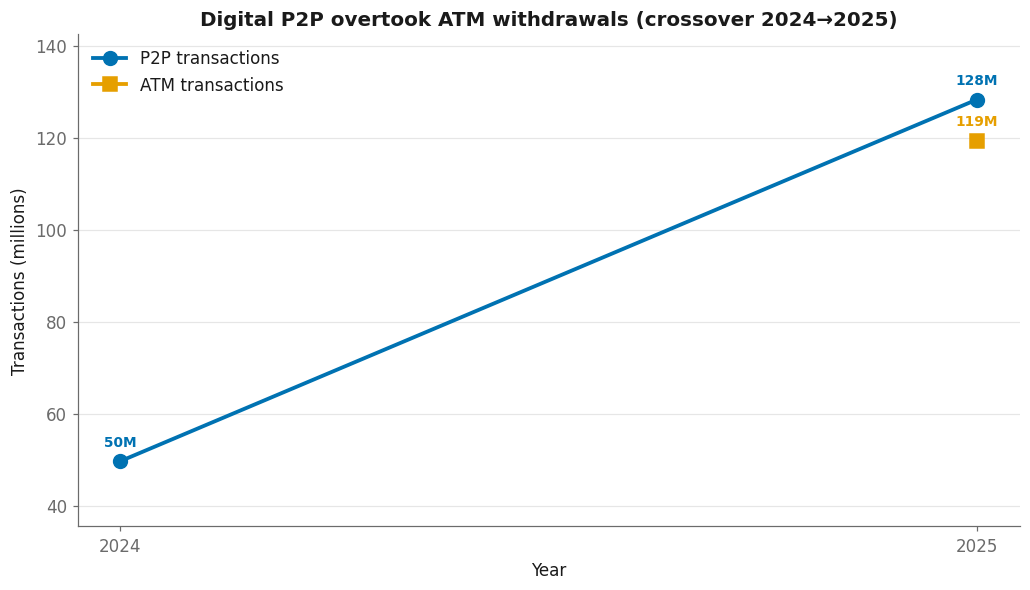

In [12]:
_ = eda.fig_p2p_atm(obs)

## 6. Infrastructure & enablers
Device and connectivity ceilings bound how far Access/Usage can realistically grow. 4G coverage nearly doubled (37.5%→70.8%), but phone ownership (41%) and smartphone adoption (40%) are the true near-term ceilings — **candidate leading indicators** for the next Findex round.

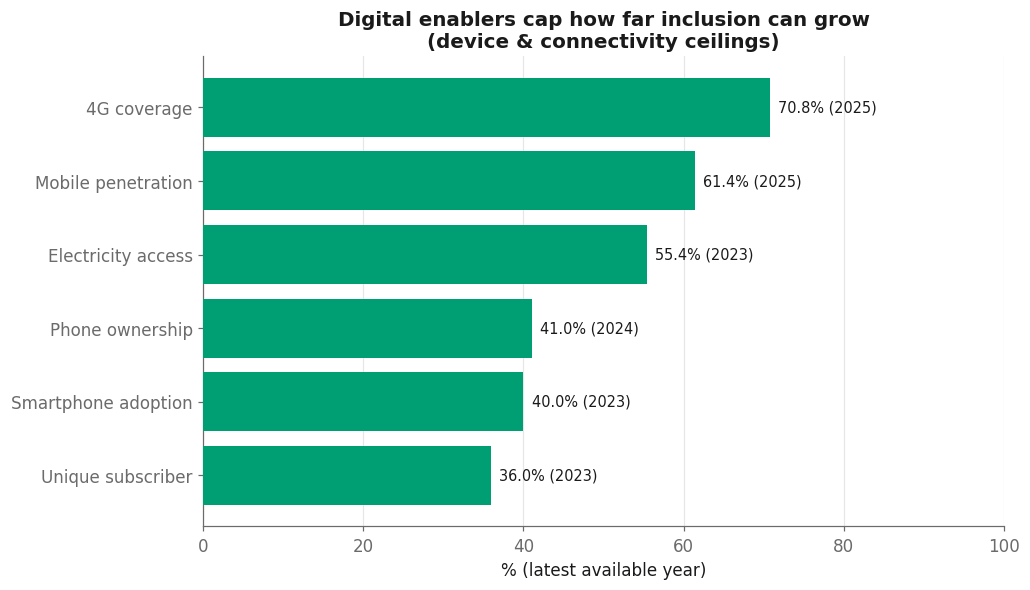

In [13]:
_ = eda.fig_enablers(obs)

## 7. Event timeline
All cataloged events (policies, launches, milestones), colored by category.

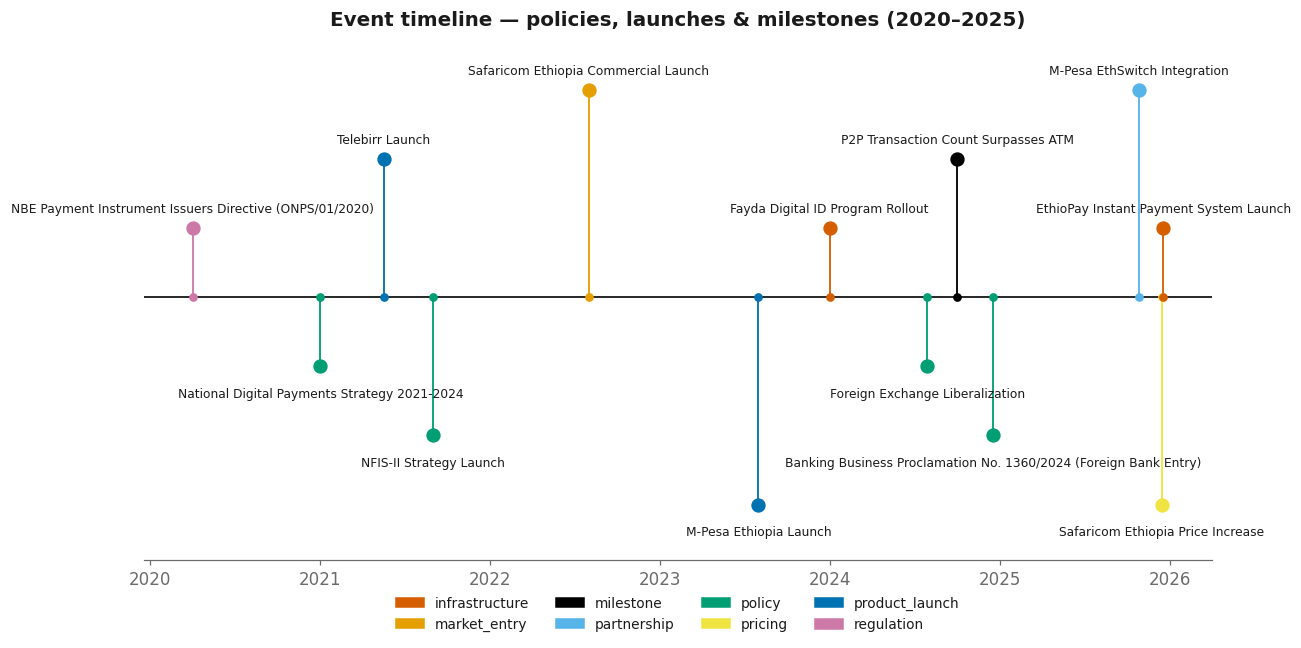

In [14]:
_ = eda.fig_timeline(d)

## 8. Relationships & correlation
**Direct time-series correlation is not feasible here:** the multi-point indicators (account ownership, Telebirr users) barely share observation years, so pairwise correlation would be spurious (n≈1 overlap). Instead we read relationships from the `impact_link` records, which encode expected event→indicator effects and their evidence basis. Note: for `AFF_DATA_INCOME` (data cost as % of GNI) an *increase* means **less** affordable.

Impact links by affected pillar:
pillar
USAGE            8
ACCESS           7
AFFORDABILITY    3
GENDER           2
DEPTH            1

By evidence basis:
evidence_basis
literature     9
empirical      6
theoretical    6


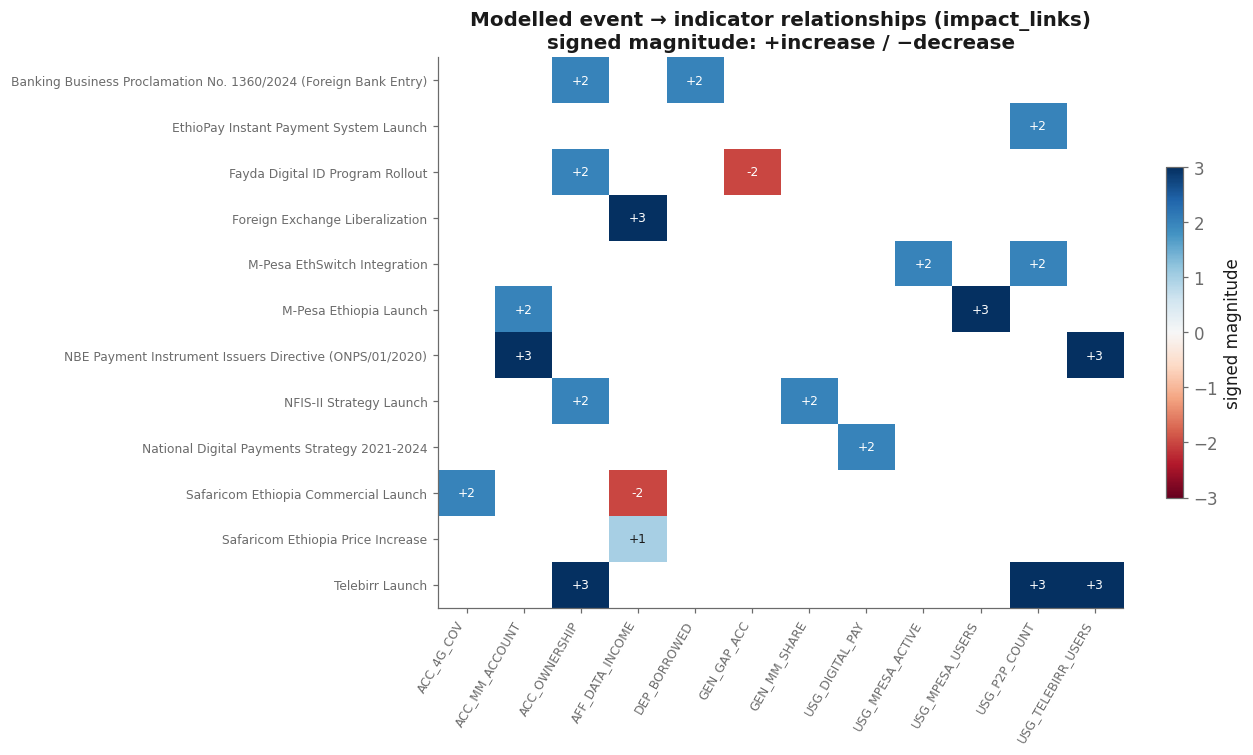

In [15]:
eda.fig_impact_matrix(d)
# What do impact_links emphasise?
il = d['impact_links']
print('Impact links by affected pillar:'); print(il.pillar.value_counts().to_string())
print('\nBy evidence basis:'); print(il.evidence_basis.value_counts().to_string())

## 9. Key insights (summary)
Full write-up with evidence in **`reports/eda_key_insights.md`**.

1. **Access has plateaued** — ownership grew only +3pp (2021→2024), decelerating to ~1pp/yr, despite 65M+ mobile-money registrations.
2. **The paradox is a measurement + market-structure artifact** — mobile-money-only users are ~0.5%; registrations went to the already-banked, so *any-account* ownership barely moved.
3. **Registered ≠ active ≠ owner** — 65M registered vs ~6.6M Findex unique owners; M-Pesa 90-day active rate is 66%; agents average <1 transaction/day.
4. **Usage is shifting digital even though access stalled** — P2P overtook ATM withdrawals; the frontier is now *usage depth*, not account supply.
5. **The gender gap is device-driven** — 15pp account gap tracks a 17pp phone-ownership gap (women 33% vs men 50%).
6. **Binding constraints are demand-side enablers** — phone (41%) & smartphone (40%) ownership are the ceilings and the best leading indicators for the next Findex.

**Hypotheses for the impact-modeling phase:**
- Telebirr/M-Pesa registrations predict *usage* (P2P volume) far better than *ownership*.
- Phone/smartphone ownership is a stronger leading indicator of Findex ownership than 4G coverage.
- NFIS-II and the 2020 payments directive act as *enabling* (slow, structural) drivers, not step-changes.